## Import Modules

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [2]:
paths=[]
labels=[]
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        label = filename.rsplit('_', 1)[-1].split('.')[0]
        labels.append(label.lower())
print('Dataset is loaded')

Dataset is loaded


In [3]:
paths[:5]

['/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_youth_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_near_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_search_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_pick_fear.wav']

In [4]:
labels[:5]

['fear', 'fear', 'fear', 'fear', 'fear']

In [5]:
# Create DataFrame
df = pd.DataFrame()
df['path'] = paths
df['label'] = labels
df.head()

,path,label
0,/kaggle/input/toronto-emotional-speech-set-tes...,fear
1,/kaggle/input/toronto-emotional-speech-set-tes...,fear
2,/kaggle/input/toronto-emotional-speech-set-tes...,fear
3,/kaggle/input/toronto-emotional-speech-set-tes...,fear
4,/kaggle/input/toronto-emotional-speech-set-tes...,fear


In [6]:
df['label'].value_counts()

label
fear       800
angry      800
disgust    800
neutral    800
sad        800
ps         800
happy      800
Name: count, dtype: int64

## Data Analysis

<Axes: xlabel='label', ylabel='count'>

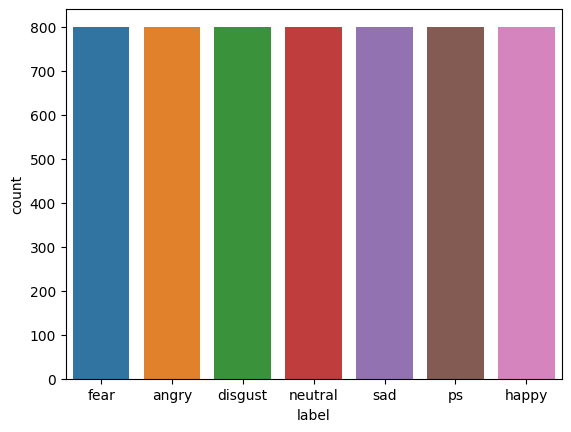

In [7]:
sns.countplot(data=df, x='label') # classes are balanced

In [8]:
def plot_wave(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def plot_spectogram(data, sr, emotion):
    x = librosa.stft(data)
    x_db = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(x_db, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

In [9]:
def display_emotion(emotion):
    path = np.array(df['path'][df['label'] == emotion])[0]
    data, sr = librosa.load(path)

    plot_wave(data, sr, emotion)
    plot_spectogram(data, sr, emotion)
    Audio(path)

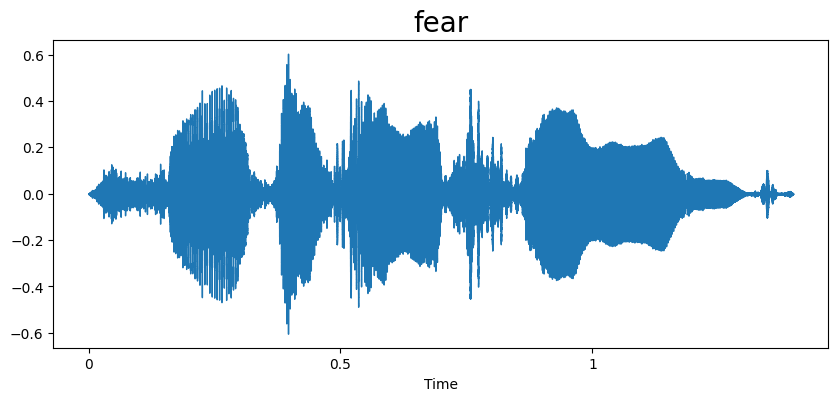

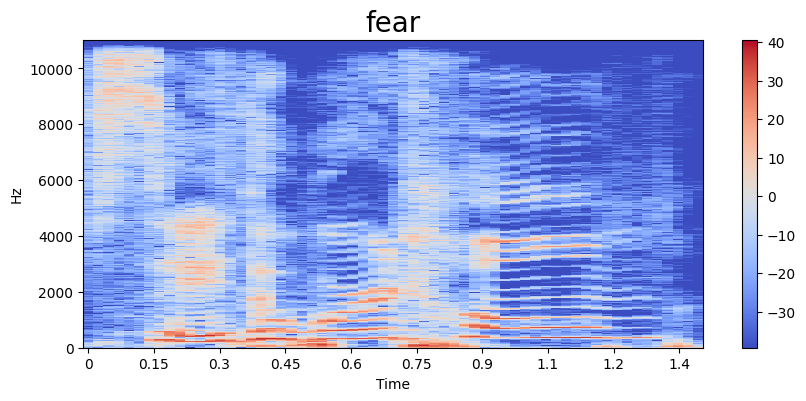

In [10]:
display_emotion('fear')

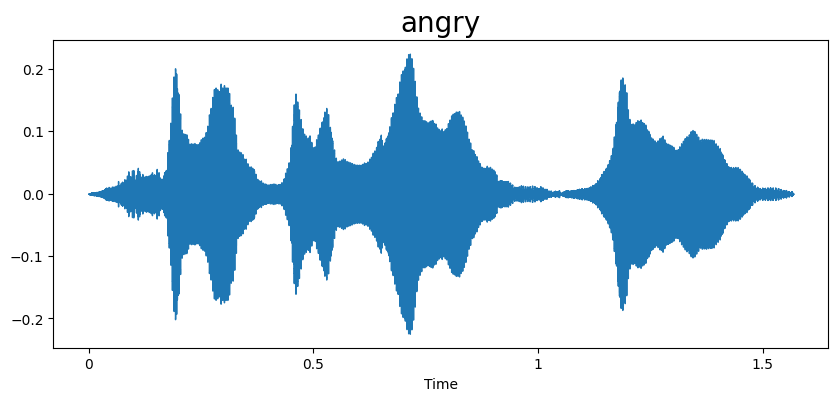

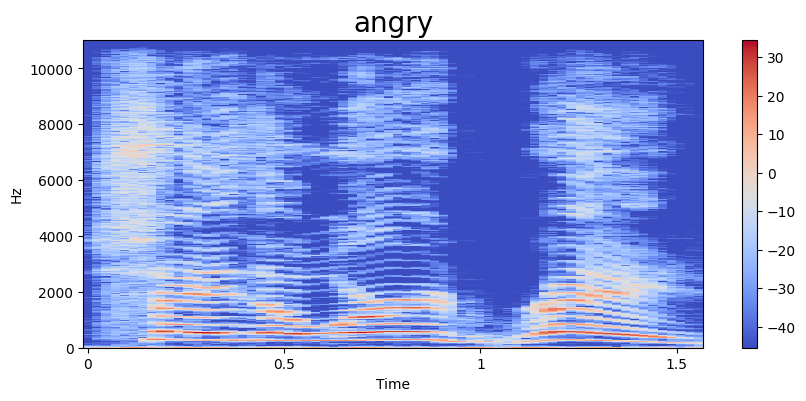

In [11]:
display_emotion('angry')

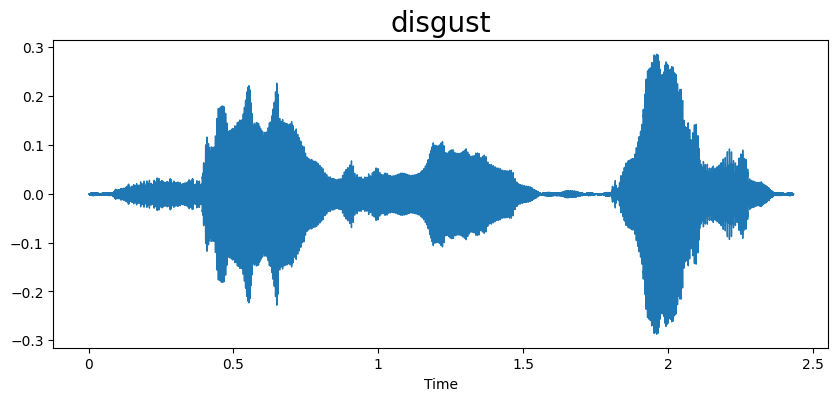

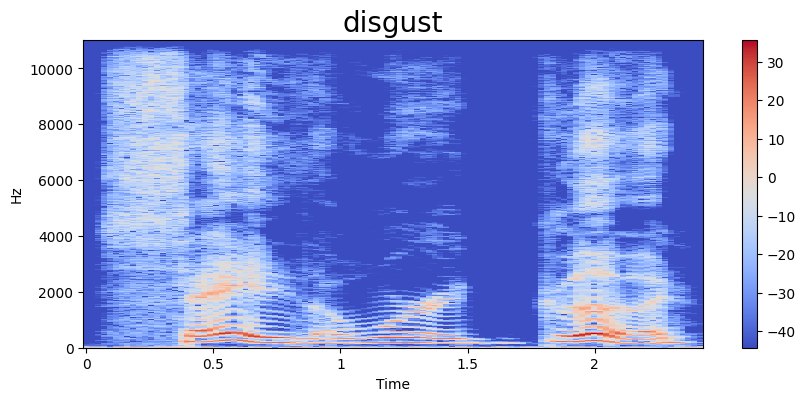

In [12]:
display_emotion('disgust')

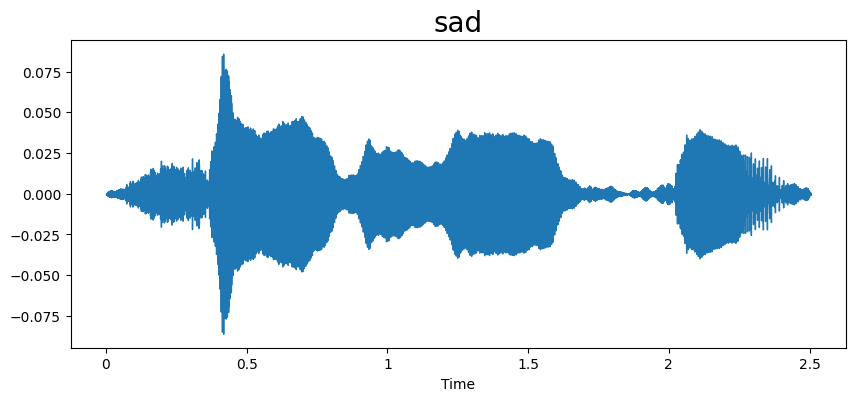

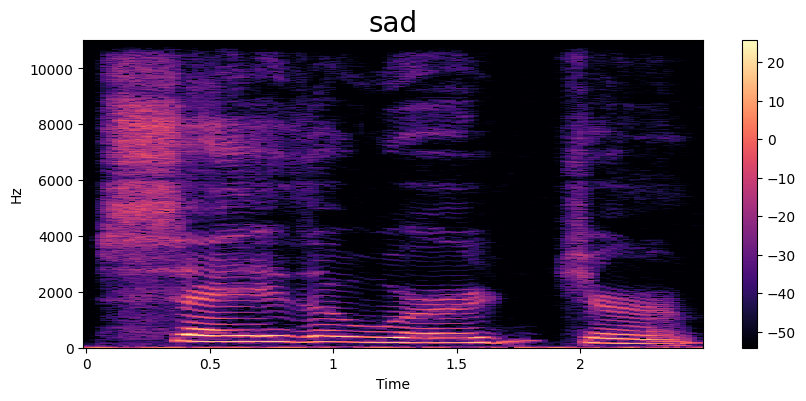

In [13]:
display_emotion('sad')

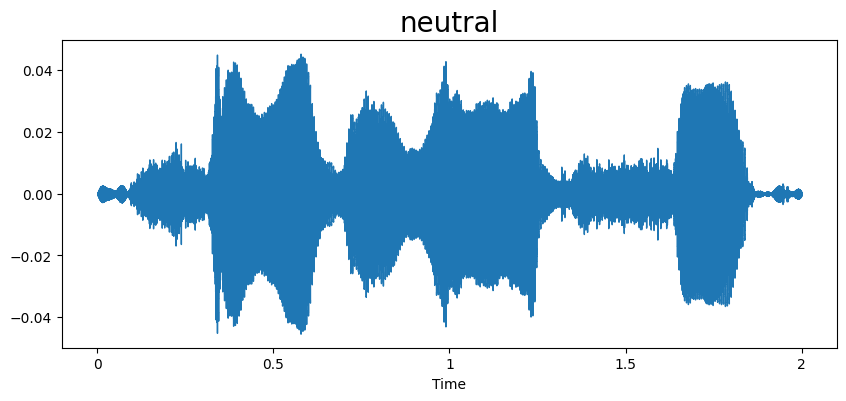

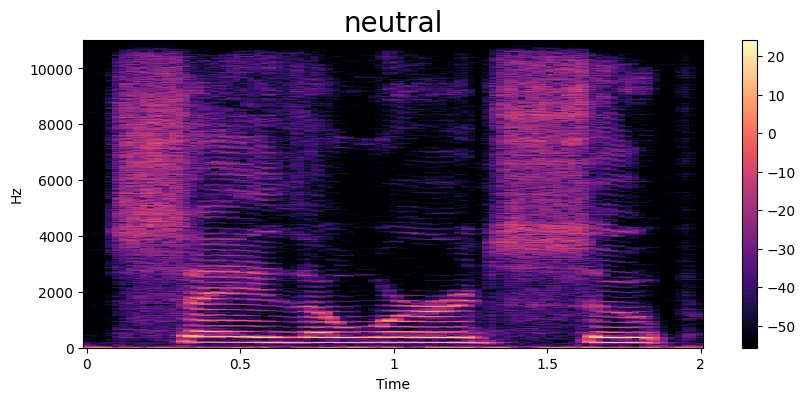

In [14]:
display_emotion('neutral')

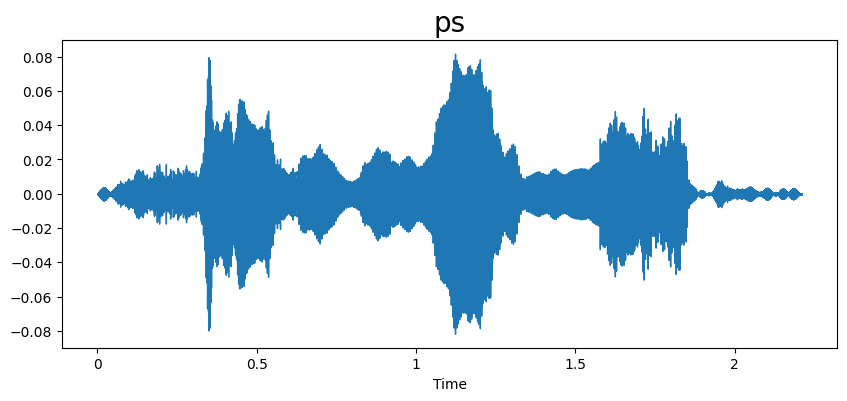

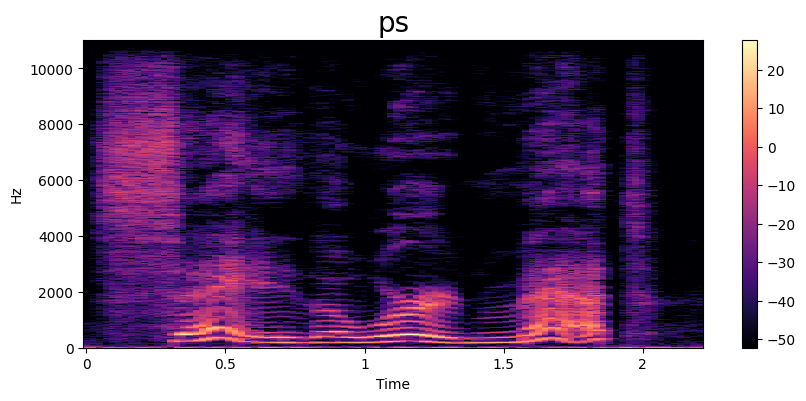

In [15]:
display_emotion('ps')

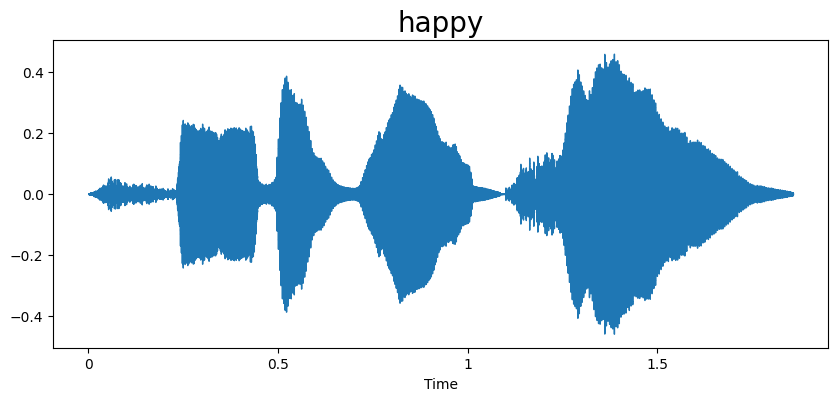

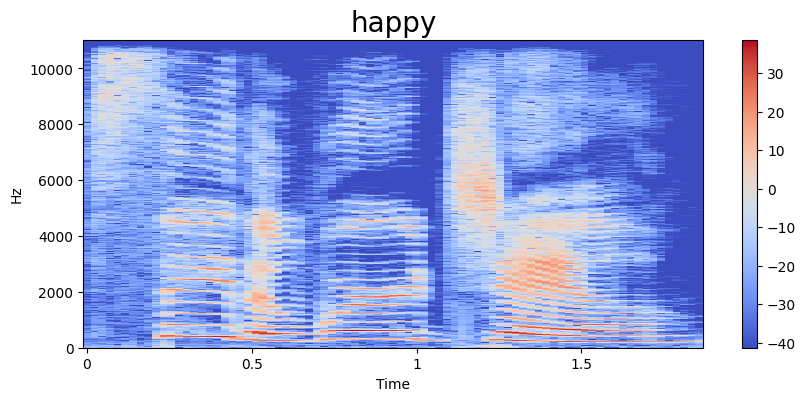

In [16]:
display_emotion('happy')

## Feature Extraction

In [17]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [18]:
extract_mfcc(df['path'][0])

array([-285.73727  ,   85.78295  ,   -2.1689112,   22.125532 ,
        -14.757396 ,   11.051346 ,   12.41245  ,   -3.000262 ,
          1.0844992,   11.078272 ,  -17.419659 ,   -8.093213 ,
          6.5879726,   -4.2209525,   -9.15508  ,    3.5214796,
        -13.186381 ,   14.078853 ,   19.66973  ,   22.725618 ,
         32.574635 ,   16.325033 ,   -3.8427296,    0.8962965,
        -11.239263 ,    6.653462 ,   -2.5883694,   -7.714016 ,
        -10.941657 ,   -2.4007545,   -5.2812867,    4.2711573,
        -11.202217 ,   -9.024621 ,   -3.6669843,    4.869744 ,
         -1.6027982,    2.5600514,   11.454374 ,   11.233449 ],
      dtype=float32)

In [19]:
X_mfcc = df['path'].apply(lambda x : extract_mfcc(x))

In [20]:
X_mfcc

0       [-285.73727, 85.78295, -2.1689112, 22.125532, ...
1       [-348.34332, 35.193233, -3.8413274, 14.658876,...
2       [-340.11435, 53.79644, -14.267782, 20.884027, ...
3       [-306.63422, 21.259705, -4.4110823, 6.4871554,...
4       [-344.7548, 46.329193, -24.171413, 19.392921, ...
                              ...                        
5595    [-374.3952, 60.864998, 0.025058484, 8.431059, ...
5596    [-313.96478, 39.847843, -5.6493053, -3.8675754...
5597    [-357.54883, 77.88606, -15.224756, 2.1946328, ...
5598    [-353.1474, 101.6839, -14.175897, -12.037376, ...
5599    [-389.4595, 54.042767, 1.3469975, -1.4258981, ...
Name: path, Length: 5600, dtype: object

In [21]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(5600, 40)

In [22]:
# Add channel
X = np.expand_dims(X, -1)
X.shape

(5600, 40, 1)

In [23]:
# Convert labels to numbers with one-hot encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
y = encoder.fit_transform(df[['label']]).toarray()

In [24]:
y.shape

(5600, 7)

## Create LSTM Model

In [25]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model =  Sequential([
    LSTM(256, return_sequences=False, input_shape=(40,1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax') # 7 as we have 7 different emotions, softmax - possibilities for each class  
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# loss='categorical_crossentropy' for multiclass classification if one-hot labels
model.summary()

2025-07-28 09:10:15.881995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753693816.163235      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753693816.244261      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-28 09:10:32.264597: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Split train and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val), 
                    epochs=50, batch_size=64)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.4947 - loss: 1.3045 - val_accuracy: 0.8268 - val_loss: 0.5270
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.8939 - loss: 0.3227 - val_accuracy: 0.9455 - val_loss: 0.1518
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.9492 - loss: 0.1733 - val_accuracy: 0.9625 - val_loss: 0.1169
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.9558 - loss: 0.1475 - val_accuracy: 0.9518 - val_loss: 0.1511
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9554 - loss: 0.1521 - val_accuracy: 0.9812 - val_loss: 0.0547
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9773 - loss: 0.0762 - val_accuracy: 0.9741 - val_loss: 0.0679
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9792 - loss: 0.0781 - val_accuracy: 0.9759 - val_loss: 0.0678
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9799 - loss: 0.0704 - val_accuracy: 0

## Plot the results

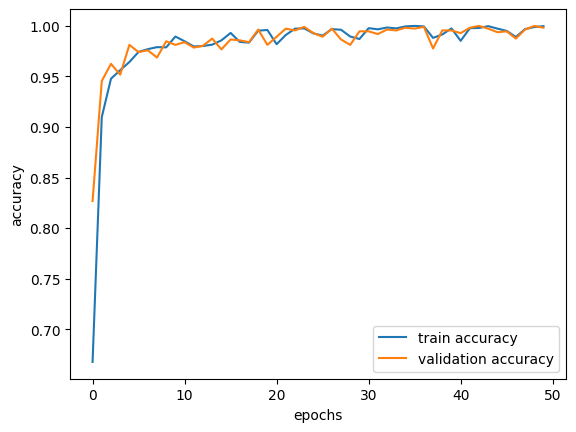

In [27]:
epochs = list(range(50))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='validation accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

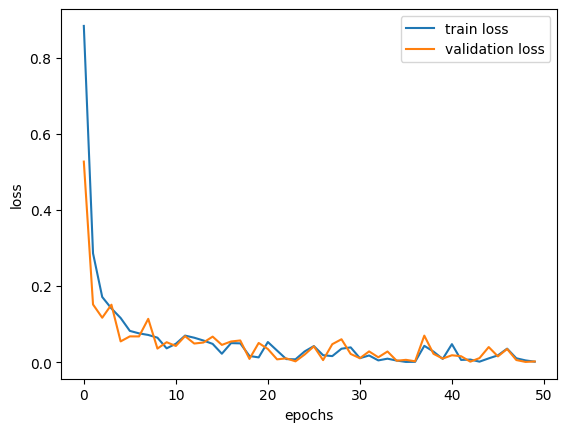

In [28]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')
plt.plot(epochs, val_loss, label='validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()